# Machine Trading Chapter 4: Artificial Intelligence Techniques

이 노트북은 공식 SPY 데이터로 책의 선형회귀·stepwise·tree rule·HMM 결과를
수치 재현하고, tree ensemble·SVM·신경망을 시간순 검증으로 다시 구현한다. 목표는
가장 예쁜 CAGR을 고르는 것이 아니라 모델 복잡도, 검증 설계, 거래 시차, 비용이
결론에 미치는 영향을 추적하는 것이다. 원본의 첫 테스트 target 1행 경계 누수도
숨기지 않고 source replay와 corrected adaptation을 분리한다.

## 1. 학습 질문과 백테스트 범위

1. 네 피처 전체 회귀가 왜 훈련에서는 좋아도 표본 외에서 사라지는가?
2. stepwise와 tree가 분산을 줄이는 방식은 무엇이며 선택 편향은 어디에 생기는가?
3. random K-fold 대신 ordered CV를 쓰면 어떤 정보 경계가 보존되는가?
4. HMM과 NN의 잠재 상태·초기화 불확실성을 어떻게 보고해야 하는가?
5. 편도 2bps와 drawdown을 포함해도 결론이 유지되는가?
6. 원본 `fwdshift`와 절반 분할 사이의 1행 경계 누수를 어떻게 보존하고 수정하는가?

여기서 전략 결과는 하루 lag를 적용한 시간순 백테스트다. 모형 구조 그림, 행렬 확률합,
누락 데이터 설명은 백테스트가 아닌 수치·개념 진단이다.

## 2. 구현 범위와 재현 상태

원본 충실 재현, published-parameter replay, boundary-corrected Python 방법론 적응,
output-only를 섞지 않는다.
공식 입력이 없는 cross-sectional 예제는 책 숫자만 보존하고 실행 결과는 `null`로 둔다.

| 주제 | 재현 상태 | 근거 |
|---|---|---|
| AI와 자동화된 패턴 탐색 | 개념 설명 | 예측보다 검증 설계가 우선 |
| 선형회귀와 과적합 | 정확 수치 재현 | lr.m, SPY 공식 MAT |
| stepwise regression | 정확 수치 재현 | 완전관측 행 고정과 ret2 선택 |
| regression tree | 정확 규칙 재현 + Python 적응 | 극단 leaf 규칙과 sklearn 전체 tree |
| cross validation | 실행된 방법론 수정 | random K-fold 대신 TimeSeriesSplit |
| bagging/random subspace | Python 적응 + output-only 원본 참조 | RandomForestRegressor, seed=1; 직접 비교 금지 |
| boosting | Python 적응 + 원본 한계 진단 | 훈련 CV로 iteration 선택 |
| classification tree | Python 적응 + provenance-uncertain 원본 참조 | 같은 주석이 5개 MATLAB 파일에 중복 |
| support vector machine | Python 적응 + output-only 원본 참조 | train-only kernel 선택 |
| hidden Markov model | published-parameter 정확 replay | 온라인 filtering, 행렬 재추정 아님 |
| neural network | 결정적 다중 seed 적응 + output-only 원본 참조 | MLP 10개와 seed 분산 |
| aggregation과 normalization | 실행 진단 | StandardScaler와 ensemble 평균 |
| technical stock selection | output-only | fundamentalData가 공식 ZIP에 없음 |
| fundamental stock selection | output-only | 저자 로컬 Dropbox 경로만 존재 |
| look-ahead/survivorship/selection bias | 개념 + 자동 검증 | 시계열 split과 테스트 격리 |
| 거래비용과 위험 | 실행 백테스트 | 2bps 편도 민감도, MDD와 duration |
| 연습문제·요약·endnotes | 커버리지 매핑 | 모형 확장과 검증 질문 |

In [1]:
from io import BytesIO
from pathlib import Path
import importlib.util
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_project_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "book3_common.py").exists():
            return candidate
    raise FileNotFoundError("Machine Trading project root not found")

PROJECT = find_project_root()
RUNNER = PROJECT / "chapter_4_artificial_intelligence_techniques/src/run_chapter4_analysis.py"
spec = importlib.util.spec_from_file_location("chapter4_analysis", RUNNER)
chapter4 = importlib.util.module_from_spec(spec)
import sys
sys.modules[spec.name] = chapter4
spec.loader.exec_module(chapter4)
data = chapter4.load_chapter_data()
results = chapter4.run_experiments(data)

def show_figure(figure):
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    plt.close(figure)
    display(Image(data=buffer.getvalue()))

print("loaded", len(data.dates), "SPY rows; split", data.split)

loaded 2357 SPY rows; split 1178


## 3. 수식과 formula-to-code 지도

단순수익률과 예측 목표는 다음과 같다.

$$ r_t(k) = (P_t - P_{t-k}) / P_{t-k} $$

$$ y_t = r_{t+1}(1) $$

`simple_returns`가 첫 식, `ols_fit`이 선형 추정, `hmm_signals`가 one-step emission,
`backtest_signals`가 signal(t) → position(t+1) → P&L을 구현한다. 수식의 행 번호와
거래 체결 시점을 같은 것으로 착각하면 look-ahead가 생긴다.

In [2]:
formula_map = pd.DataFrame([
    ("simple return", "simple_returns", "lags 1/2/5/20"),
    ("OLS", "ols_fit", "book coefficients"),
    ("stepwise", "forward_stepwise_fit", "ret2 selection"),
    ("HMM forecast", "hmm_signals", "stochastic matrices"),
    ("source/corrected boundary", "valid_training_arrays", "last target precedes test"),
    ("causal P&L", "backtest_signals", "first position is zero"),
], columns=["formula or contract", "implementation", "verification"])
display(formula_map)

,formula or contract,implementation,verification
0,simple return,simple_returns,lags 1/2/5/20
1,OLS,ols_fit,book coefficients
2,stepwise,forward_stepwise_fit,ret2 selection
3,HMM forecast,hmm_signals,stochastic matrices
4,source/corrected boundary,valid_training_arrays,last target precedes test
5,causal P&L,backtest_signals,first position is zero


## 4. 공식 출처, checksum, 잠금 환경

저자 페이지와 직접 ZIP URL, archive SHA-256, 각 멤버 checksum, `uv.lock` SHA-256을
함께 기록한다. URL만 있으면 같은 이름의 파일이 교체돼도 감지하지 못한다. random seed는
PCG64를 직접 쓰는 시뮬레이션 대신 각 sklearn estimator의 `random_state=1`에 고정하며,
MLP는 seed 1~10 전체를 보고한다.

In [3]:
manifest = chapter4.chapter_manifest()
provenance = pd.Series({
    "source_page": manifest["source_page"],
    "archive_url": manifest["url"],
    "archive_sha256": manifest["sha256"],
    "input_sha256": next(m["sha256"] for m in json.loads(chapter4.SOURCE_MANIFEST_PATH.read_text())["members"] if m["archive_path"].endswith("inputData_SPY.mat")),
    "uv.lock SHA-256": chapter4.sha256_file(chapter4.UV_LOCK_PATH),
})
display(provenance.to_frame("value"))
display(pd.Series(chapter4.environment_versions(("numpy","pandas","scipy","matplotlib","scikit-learn","nbformat","nbclient"))).to_frame("environment version"))

,value
source_page,https://epchan.com/book3
archive_url,https://epchan.com/img/book3/Chap4%20AI.zip
archive_sha256,a556978ebe871446b3f32511a910b8fec74669bc02dddc...
input_sha256,b94aa1b85d10e4e41c021882ee90a7d945341baf8d4690...
uv.lock SHA-256,34057457773a614f058648f3ba9ba2f02f02354f64214e...


,environment version
python,3.12.3
numpy,2.5.1
pandas,3.0.3
scipy,1.18.0
matplotlib,3.11.1
scikit-learn,1.9.0
nbformat,5.10.4
nbclient,0.11.0


## 5. 데이터 구조·결측·분할 진단

공식 MAT에는 SPY open, close, YYYYMMDD가 있다. close 결측과 비양수 가격을 먼저
거부하고 날짜 중복도 거부한다. 피처는 중첩수익률이라 서로 강하게 상관될 수 있고 첫
20행은 ret20 때문에 비어 있다. MATLAB stepwise는 최종 ret2 모델이라도 네 후보의
완전관측 1,158행을 고정한다. 이 미묘한 행 규칙을 지켜야 원본 계수가 재현되지만,
마지막 행의 target은 첫 테스트 수익이다. corrected 모델은 1,157행만 쓴다.

,value
rows,2357
start,2004-12-22
end,2014-06-02
train rows,1178
test rows,1179
train end,2009-09-15
test start,2009-09-16
missing close,0
nonpositive close,0
complete train model rows,1158


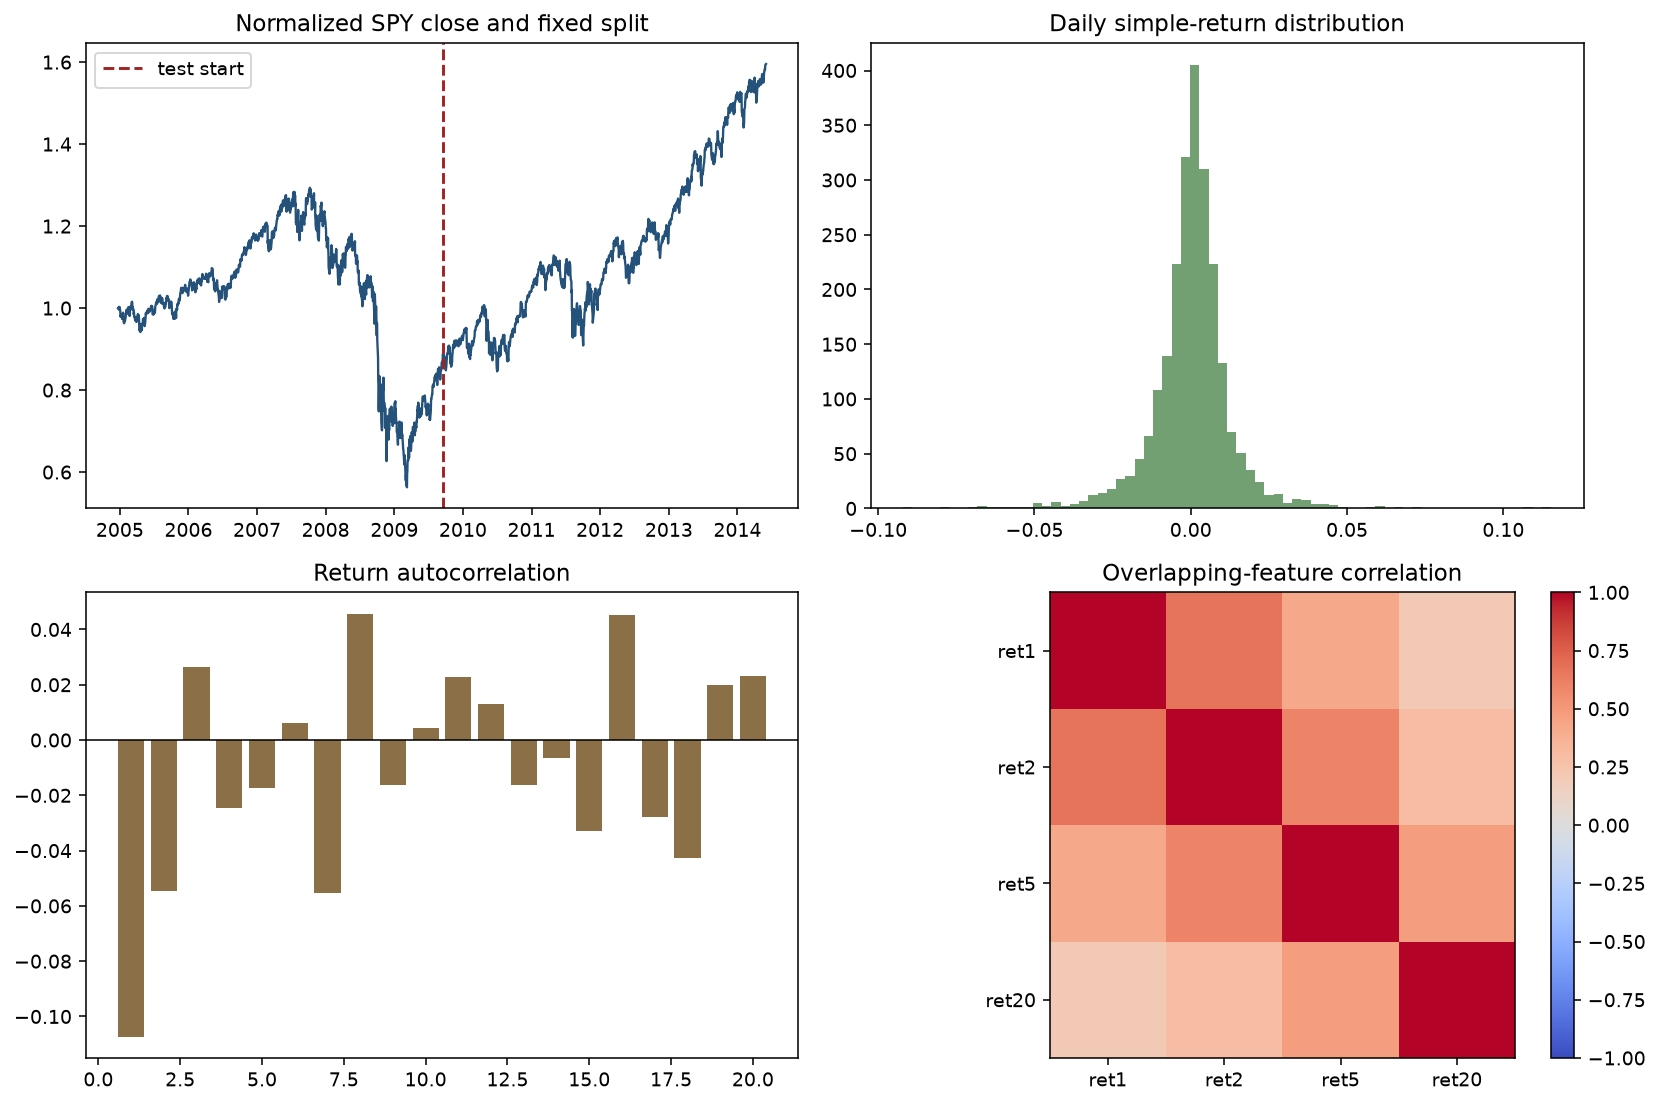

In [4]:
diagnostics = pd.Series({
    "rows": len(data.dates),
    "start": data.dates[0].date(),
    "end": data.dates[-1].date(),
    "train rows": data.split,
    "test rows": len(data.dates) - data.split,
    "train end": data.dates[data.split-1].date(),
    "test start": data.dates[data.split].date(),
    "missing close": int(np.count_nonzero(~np.isfinite(data.close_prices))),
    "nonpositive close": int(np.count_nonzero(data.close_prices <= 0)),
    "complete train model rows": int(np.count_nonzero(np.all(np.isfinite(data.features[:data.split]), axis=1) & np.isfinite(data.target[:data.split]))),
    "causal train model rows": len(chapter4.valid_training_arrays(data)[0]),
})
display(diagnostics.to_frame("value"))
assert diagnostics["missing close"] == 0 and diagnostics["nonpositive close"] == 0
show_figure(chapter4.create_data_diagnostics_figure(data))

## 6. 모형에서 거래까지의 인과 지도

관측 데이터 → lagged feature → boundary-corrected train-only fit → 다음 날 signal →
하루 뒤 P&L의 순서를 고정한다. 테스트 시작일의 position은 반드시 0이다. 검증 fold도
train 마지막 행보다 validation 첫 행이 뒤에 있어야 한다. 이 지도는 modern adaptation
계약이며 source exact replay의 경계 누수는 별도로 보존한다.

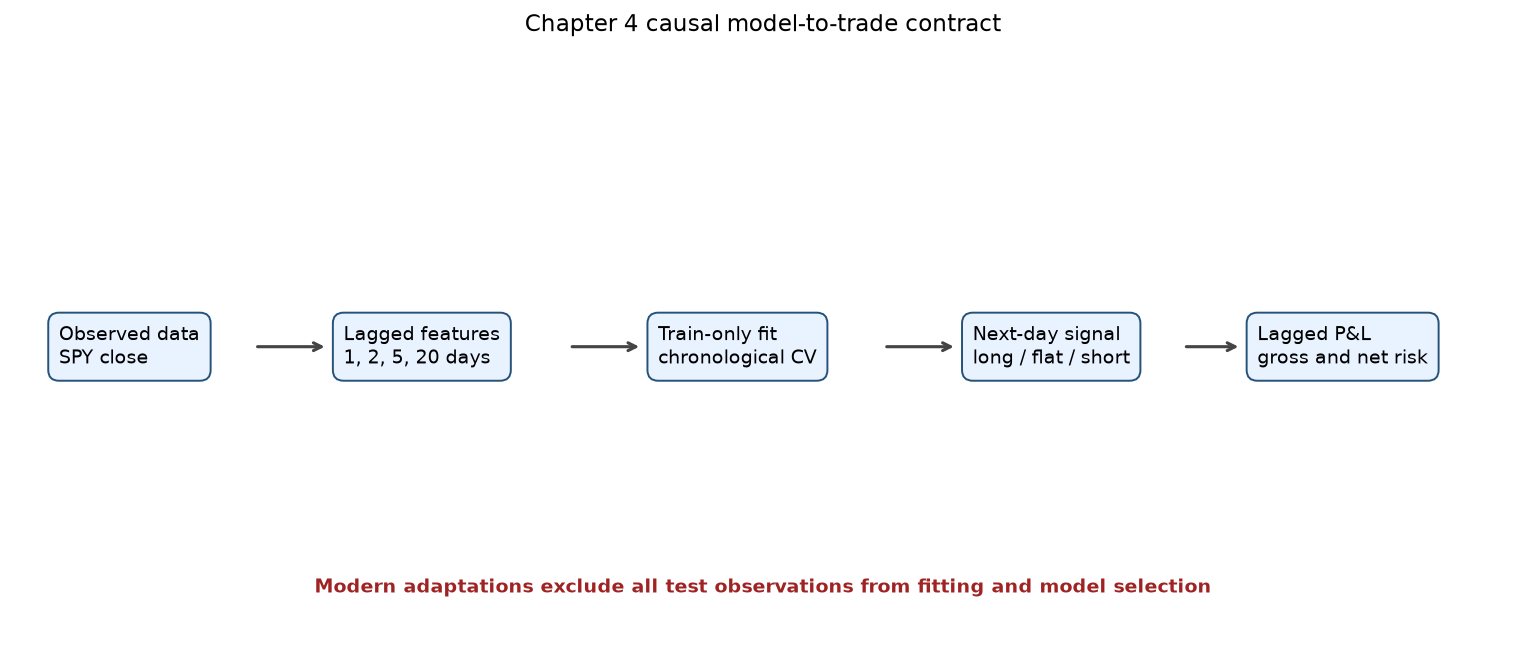

In [5]:
show_figure(chapter4.create_model_map_figure())
assert results["linear"]["test"].positions[0] == 0
assert all(b["train_last"] < b["validation_first"] for b in results["python_models"]["cv_boundaries"])

## 7. Full linear regression: 훈련 성공의 붕괴

네 피처를 모두 쓴 OLS 계수는 `lr.m`과 거의 machine precision으로 일치한다. 하지만
훈련 CAGR 약 34%가 테스트 약 0.4%로 줄어든다. ret1, ret2, ret5, ret20이 중첩돼
다중공선성이 있고 약한 예측 신호에 비해 추정 자유도가 많다. 훈련 적합도가 높다는 사실은
표본 외 경제적 가치와 같지 않다. 이 exact 숫자는 원본처럼 훈련 마지막 predictor의
target으로 첫 테스트 수익을 사용한다. 아래에 그 1행을 제외한 corrected 결과를 함께 둔다.

In [6]:
linear_table = pd.DataFrame({
    "Python coefficient": results["linear"]["coefficients"],
    "book/source coefficient": chapter4.BOOK_LINEAR_COEFFICIENTS,
    "p-value": results["linear"]["p_values"],
}, index=["intercept", *chapter4.FEATURE_NAMES])
display(linear_table)
display(pd.DataFrame({
    "train": results["linear"]["train"].gross.__dict__,
    "source-defined test": results["linear"]["test"].gross.__dict__,
    "boundary-corrected test": results["linear"]["causal"]["test"].gross.__dict__,
}).loc[["annual_return","sharpe","maximum_drawdown","drawdown_duration"]])
display(pd.Series({
    "source fit rows": results["linear"]["observations"],
    "corrected fit rows": results["linear"]["causal"]["observations"],
    "source last target": results["linear"]["test"].metadata["last_fit_target_realization_date"],
    "corrected last target": results["linear"]["causal"]["test"].metadata["last_fit_target_realization_date"],
    "test start": results["linear"]["causal"]["test"].metadata["test_start"],
}).to_frame("value"))
assert np.allclose(results["linear"]["coefficients"], chapter4.BOOK_LINEAR_COEFFICIENTS, atol=2e-14, rtol=0)

,Python coefficient,book/source coefficient,p-value
intercept,0.000046,0.000046,0.917164
ret1,-0.024973,-0.024973,0.517197
ret2,-0.130977,-0.130977,0.000087
ret5,0.013964,0.013964,0.507852
ret20,0.001731,0.001731,0.851807


,train,source-defined test,boundary-corrected test
annual_return,0.343339,0.003582,0.011817
sharpe,1.365304,0.103952,0.153771
maximum_drawdown,-0.216440,-0.295969,-0.295969
drawdown_duration,78.000000,778.000000,778.000000


,value
source fit rows,1158
corrected fit rows,1157
source last target,2009-09-16
corrected last target,2009-09-15
test start,2009-09-16


## 8. Stepwise regression: 분산 감소와 선택 편향

forward entry p-value가 가장 작은 ret2만 선택된다. 훈련 CAGR 약 44%, 테스트 약 11%로
full model보다 낫지만 이 표본 하나가 stepwise의 일반적 우월성을 증명하지 않는다.
후보 lag나 진입 문턱을 테스트 결과를 보며 바꾸면 selection bias다. 여기에 저장된
candidate p-value는 선택 과정 자체를 감사할 수 있게 한다. source-defined와 corrected
적합 모두 ret2를 선택하지만 계수와 결과는 별도로 기록한다.

In [7]:
display(pd.Series(results["stepwise"]["candidate_p_values"]).sort_values().to_frame("entry p-value"))
comparison = pd.DataFrame({
    "Python CAGR": [results["linear"]["test"].gross.annual_return, results["stepwise"]["test"].gross.annual_return],
    "book/source CAGR": [chapter4.BOOK_RESULTS["linear_test_cagr"], chapter4.BOOK_RESULTS["stepwise_test_cagr"]],
    "Python Sharpe": [results["linear"]["test"].gross.sharpe, results["stepwise"]["test"].gross.sharpe],
}, index=["full linear", "stepwise ret2"])
display(comparison)
display(pd.DataFrame({
    "source-defined": [results["stepwise"]["test"].gross.annual_return, results["stepwise"]["test"].gross.sharpe],
    "boundary-corrected": [results["stepwise"]["causal"]["test"].gross.annual_return, results["stepwise"]["causal"]["test"].gross.sharpe],
}, index=["test CAGR", "test Sharpe"]))
assert results["stepwise"]["selected"] == ["ret2"]

,entry p-value
ret2,4.322269e-09
ret1,1.646151e-05
ret5,3.750269e-03
ret20,2.006203e-01


,Python CAGR,book/source CAGR,Python Sharpe
full linear,0.003582,0.003582,0.103952
stepwise ret2,0.105685,0.105685,0.695228


,source-defined,boundary-corrected
test CAGR,0.105685,0.107317
test Sharpe,0.695228,0.704249


## 9. Regression tree: 전체 tree와 extreme leaves

tree는 비선형 조건을 쉽게 표현하지만 작은 표본의 분할을 기억하기도 쉽다. 책의 전체
tree 예측은 훈련에서 높고 테스트에서 음수다. 극단 leaf 두 개만 거래하는 규칙은 flat을
허용해 더 보수적이다. 아래 곡선은 선형·stepwise·극단 tree·HMM을 동일 train/test
구간으로 분리해 보여준다. 서로 다른 구간을 한 wealth curve로 이어붙이지 않는다.

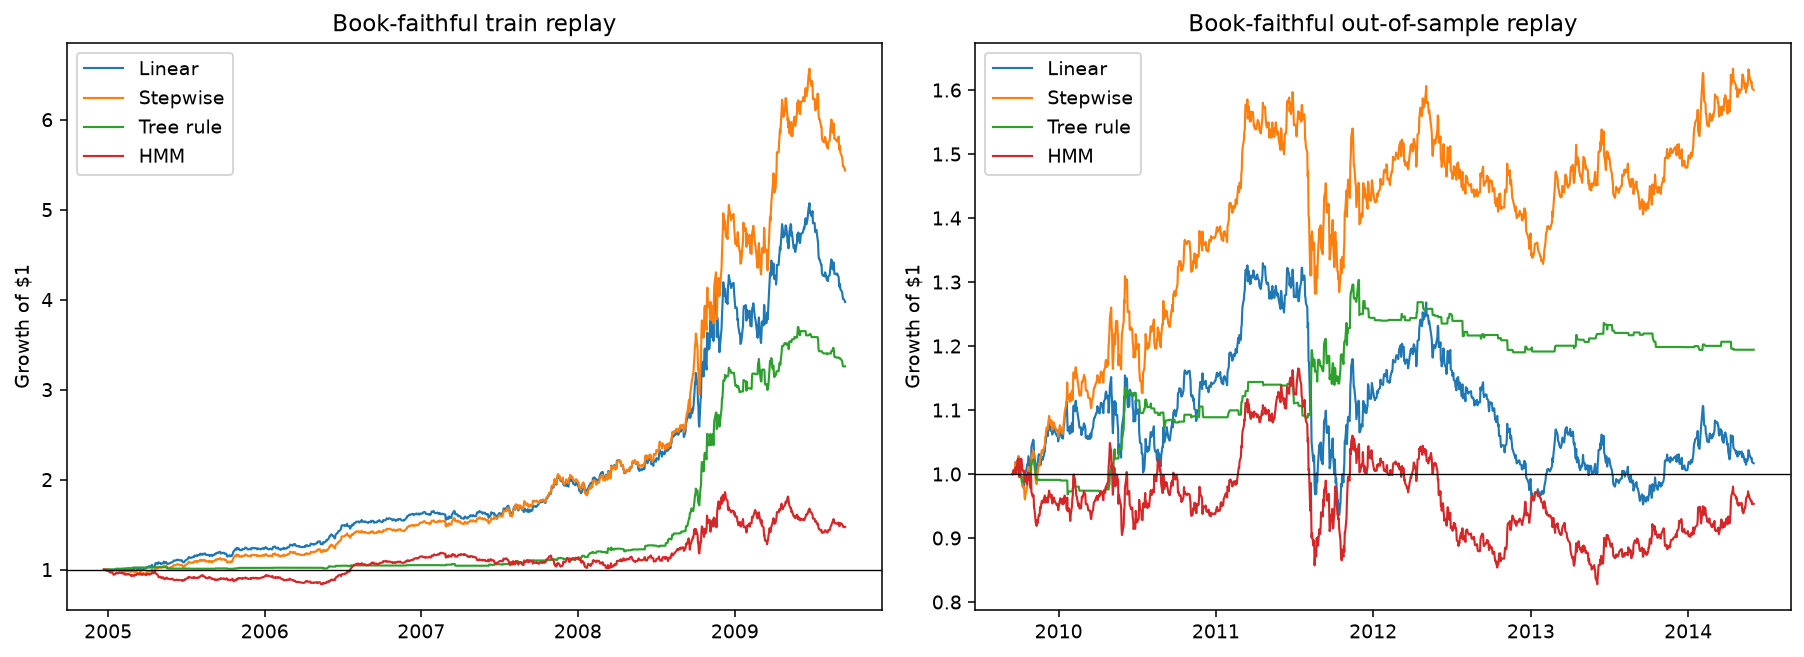

,value
Python test CAGR,0.038665
book/source test CAGR,0.038665
active fraction,0.189992


In [8]:
show_figure(chapter4.create_book_replay_figure(data, results))
tree_compare = pd.Series({
    "Python test CAGR": results["tree_rule"]["test"].gross.annual_return,
    "book/source test CAGR": chapter4.BOOK_RESULTS["tree_rule_test_cagr"],
    "active fraction": np.mean(np.abs(results["tree_rule"]["test"].positions) > 0),
})
display(tree_compare.to_frame("value"))

## 10. Bagging, random subspace, boosting

Bagging은 bootstrap 표본의 tree를 평균해 분산을 낮추고, random subspace는 tree마다
피처 일부만 보여 상관을 낮춘다. Boosting은 앞 learner의 오차를 다음 learner가 보완한다.
원본은 여러 iteration의 test 성능을 그려 사실상 test를 모델 선택에 노출한다. 여기서는
boosting iteration을 train ordered CV로만 선택하고 test는 한 번 평가한다. 원본 bagging,
classification tree, SVM, NN 숫자는 estimator·split·RNG가 달라 output-only reference로
나란히 표시하되 일치 여부를 판정하지 않는다. classification 값은 같은 주석이 MATLAB
5개에 중복돼 provenance가 특히 불확실하다.

,gross CAGR,net CAGR at 2bps,gross Sharpe,max drawdown
tree,-0.108415,-0.144899,-0.618364,-0.455200
classification_tree,0.039669,0.000543,0.319308,-0.260413
random_forest,0.087037,0.047773,0.590903,-0.256122
boosting,-0.022032,-0.061155,-0.054078,-0.347782
svm,0.112014,0.111586,0.730285,-0.263728
mlp_ensemble,-0.030418,-0.059697,-0.106211,-0.317091


,book_or_source,python_adaptation,compared,reason
topic,,,,
bagging/random subspace,"{'annual_return': 0.071967, 'sharpe': 0.505925}","{'annual_return': 0.08703706652791965, 'sharpe...",False,MATLAB TreeBagger split and random-subspace de...
classification tree,"{'annual_return': 0.04774, 'sharpe': 0.366381}","{'annual_return': 0.03966949530300634, 'sharpe...",False,The identical output comment appears in rTree....
support vector machine,"{'annual_return': 0.13353, 'sharpe': 0.847489}","{'annual_return': 0.11201427618460813, 'sharpe...",False,random-fold MATLAB estimator differs from trai...
neural-network average,"{'annual_return': 0.078454, 'sharpe': 0.542809}","{'annual_return': -0.03041823720380732, 'sharp...",False,"network architecture, solver, validation, and ..."


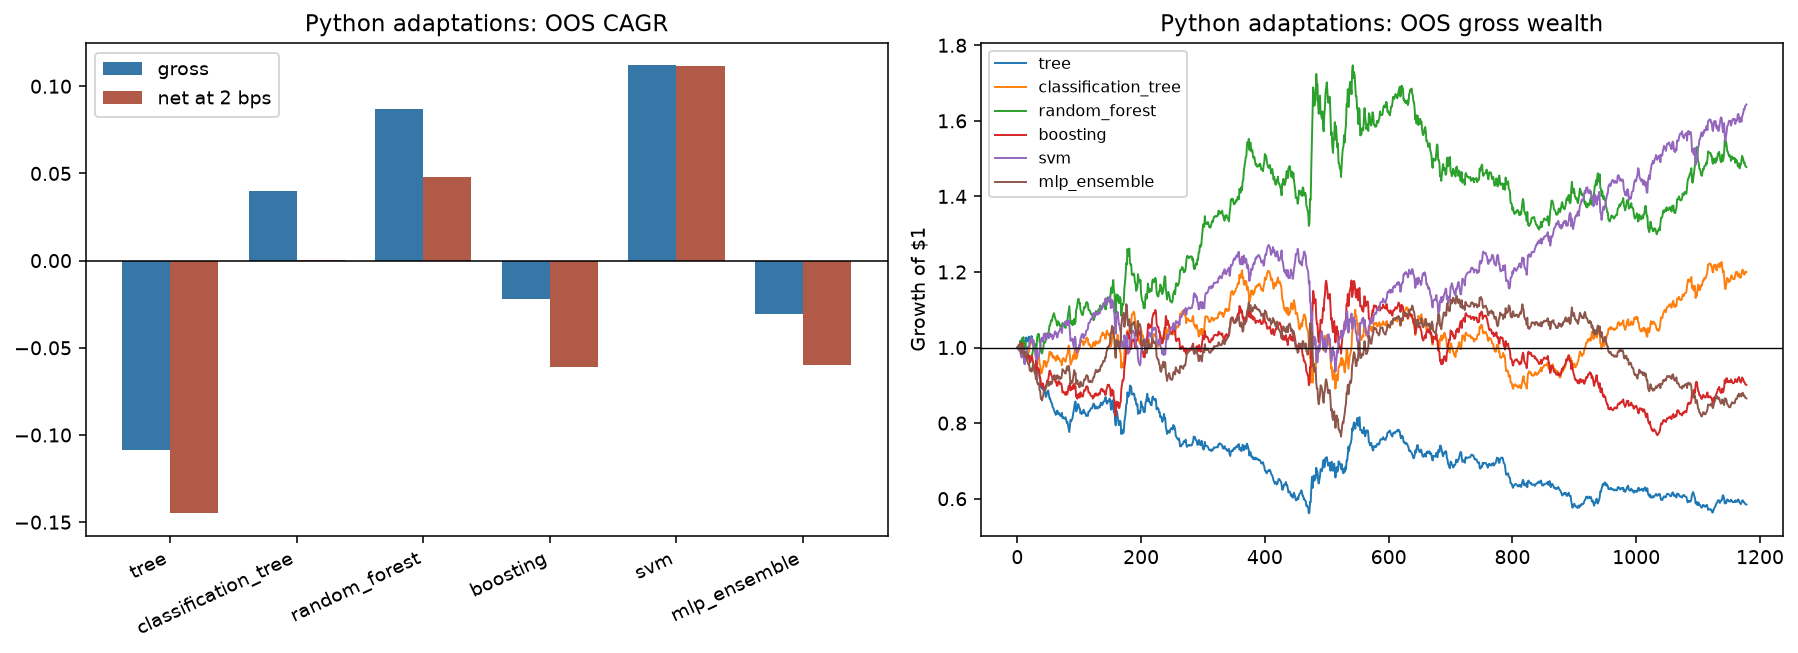

In [9]:
models = chapter4.python_model_results(results)
model_table = pd.DataFrame({
    "gross CAGR": {k: v.gross.annual_return for k, v in models.items()},
    "net CAGR at 2bps": {k: v.net.annual_return for k, v in models.items()},
    "gross Sharpe": {k: v.gross.sharpe for k, v in models.items()},
    "max drawdown": {k: v.gross.maximum_drawdown for k, v in models.items()},
})
display(model_table)
display(pd.DataFrame(chapter4.reference_only_comparisons(results)).set_index("topic")[["book_or_source","python_adaptation","compared","reason"]])
show_figure(chapter4.create_python_model_figure(results))

## 11. Classification tree와 SVM

회귀는 다음 날 수익률 크기를 예측하지만 classification은 부호를 직접 예측한다. SVM은
margin을 최대화하며 kernel로 비선형 경계를 만든다. 스케일이 거리와 margin에 영향을
주므로 `StandardScaler`를 train pipeline 안에 둔다. kernel은 ordered CV accuracy로만
고르고, 책의 random-fold SVM 숫자는 원본 출력 비교이지 같은 estimator라고 주장하지 않는다.

In [10]:
svm_meta = results["python_models"]["svm"].metadata
display(pd.Series(svm_meta["cv_accuracy_by_kernel"]).to_frame("mean ordered-CV accuracy"))
print("selected kernel:", svm_meta["selected_kernel"])
print("book default-SVM OOS CAGR/Sharpe:", chapter4.BOOK_RESULTS["svm_test_cagr"], chapter4.BOOK_RESULTS["svm_test_sharpe"])
print("Python adaptation OOS CAGR/Sharpe:", results["python_models"]["svm"].gross.annual_return, results["python_models"]["svm"].gross.sharpe)

,mean ordered-CV accuracy
linear,0.532292
polynomial,0.541667
rbf,0.535417


selected kernel: polynomial
book default-SVM OOS CAGR/Sharpe: 0.13353 0.847489
Python adaptation OOS CAGR/Sharpe: 0.11201427618460813 0.7302850327761891


## 12. HMM: 관측 부호 뒤의 잠재 상태

두 hidden state와 양/음 return observation을 둔다. 아래 transition·emission의 각 행은
1이어야 한다. Python은 원본에 인쇄된 행렬을 replay하므로 CAGR은 정확히 맞지만 EM
재추정의 독립 재현은 아니다. `hmm.m`과 `hmm_train2.m`의 중단 assert 때문에 이 경계를
명시하지 않으면 재현 수준을 과장하게 된다.

In [11]:
display(pd.DataFrame(chapter4.HMM_TRANSITION, index=["state 1","state 2"], columns=["next 1","next 2"]))
display(pd.DataFrame(chapter4.HMM_EMISSION, index=["state 1","state 2"], columns=["negative","nonnegative"]))
hmm_compare = pd.DataFrame({
    "Python": [results["hmm"]["train"].gross.annual_return, results["hmm"]["test"].gross.annual_return],
    "book/source": [chapter4.BOOK_RESULTS["hmm_train_cagr"], chapter4.BOOK_RESULTS["hmm_test_cagr"]],
}, index=["train CAGR","test CAGR"])
display(hmm_compare)
assert np.allclose(chapter4.HMM_TRANSITION.sum(axis=1), 1)
assert np.allclose(chapter4.HMM_EMISSION.sum(axis=1), 1)

,next 1,next 2
state 1,0.595800,0.404200
state 2,0.748746,0.251254


,negative,nonnegative
state 1,0.190513,0.809487
state 2,0.973038,0.026962


,Python,book/source
train CAGR,0.086644,0.086644
test CAGR,-0.010173,-0.010173


## 13. Neural network, normalization, aggregation

신경망은 초기 weight와 validation 분할에 민감하다. 한 seed의 좋은 결과를 고르는 대신
동일 구조를 seed 1~10으로 모두 실행하고 예측을 평균한다. 입력은 train 안에서 표준화하고
목표도 train 평균·표준편차로만 정규화한다. seed별 OOS CAGR 분산은 model uncertainty의
간단한 진단이지 신뢰구간이나 미래 성능 보장이 아니다. 무작위 내부 validation은 쓰지
않고 모든 seed에 같은 500-iteration 예산을 적용해 시간순 계약을 흐리지 않는다.

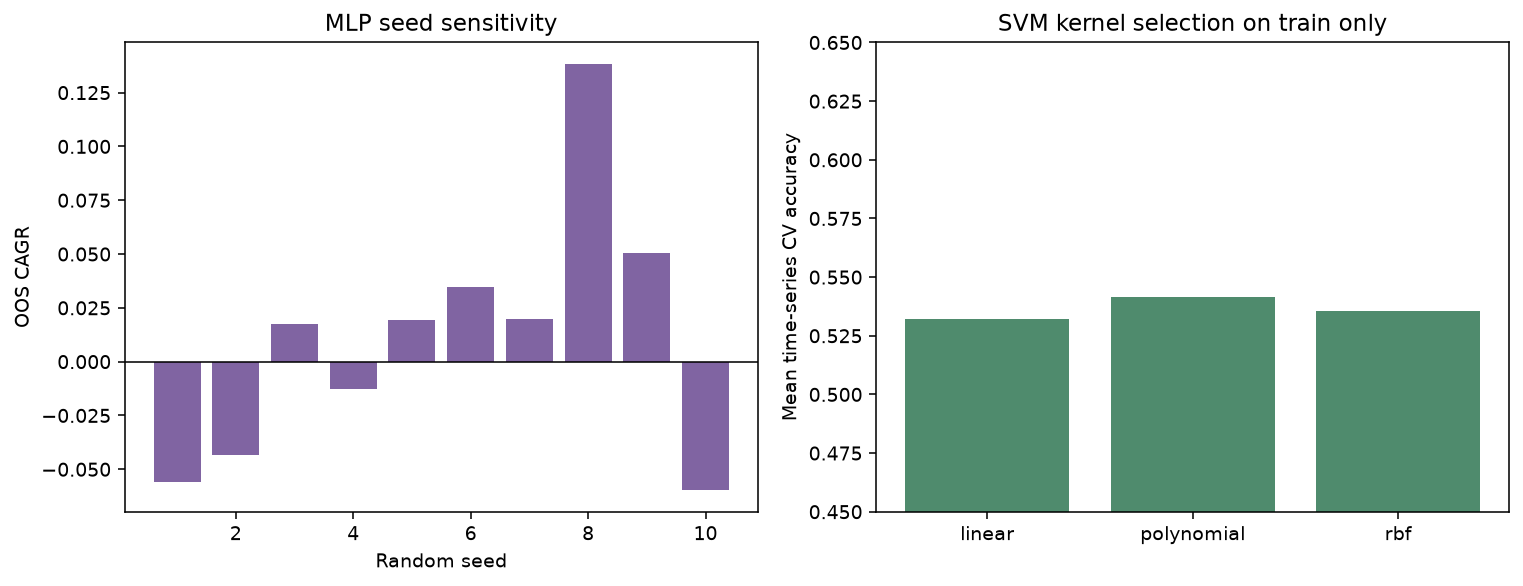

,OOS CAGR
minimum,-0.059825
median,0.018335
maximum,0.138376
ensemble,-0.030418


In [12]:
show_figure(chapter4.create_seed_stability_figure(results))
seed_cagrs = results["python_models"]["mlp_ensemble"].metadata["seed_cagrs"]
display(pd.Series({"minimum": min(seed_cagrs), "median": float(np.median(seed_cagrs)), "maximum": max(seed_cagrs), "ensemble": results["python_models"]["mlp_ensemble"].gross.annual_return}).to_frame("OOS CAGR"))

## 14. Cross-sectional stock selection은 왜 output-only인가

기술 피처와 fundamental 피처의 주식선택 스크립트는 저자 로컬 Dropbox의
`fundamentalData`를 읽는다. 공식 ZIP에는 그 파일, point-in-time universe, delisted
종목, 당시 fundamentals가 없다. 현재 구성종목 데이터로 대체하면 survivorship bias와
시점 불일치가 생긴다. 그래서 책의 2.3%/0.9와 4.0%/1.1은 보존하되 실행 test는 `null`이다.

In [13]:
unavailable = pd.DataFrame(results["unavailable"]).T
display(unavailable[["status","test","reason"]])
assert unavailable["test"].isna().all()
display(pd.DataFrame(chapter4.source_incomplete_markers().items(), columns=["source file","disclosed stop marker"]))

,status,test,reason
technical_stock_selection,unavailable_data,None,rTree_SPX.m loads a private fundamentalData fi...
fundamental_stock_selection,unavailable_data,None,stepwiseLR_SPX.m loads the author's local Drop...


,source file,disclosed stop marker
0,hmm.m,INCOMPLETE!
1,hmm_train2.m,Does not work
2,nn_retrain.m,INCOMPLETE!
3,stepwiseLR_SPX_fillFwd.m,TODO


## 15. 거래비용, slippage, 위험지표

편도 2bps는 포지션 변화량에 곱한다. -1에서 +1 전환은 두 단위 turnover라 4bps다.
net CAGR은 어떤 전략에서도 gross보다 좋아질 수 없다. 다만 이 민감도에는 실제 spread,
slippage, borrow fee, latency, market impact가 빠져 있으므로 실현 가능성의 하한이 아니라
낙관적 진단이다. Sharpe와 CAGR 외에 maximum drawdown, drawdown duration, annual
turnover를 함께 본다.

In [14]:
cost_table = pd.DataFrame({
    "gross CAGR": {k: v.gross.annual_return for k, v in models.items()},
    "net CAGR": {k: v.net.annual_return for k, v in models.items()},
    "annual turnover": {k: v.gross.annual_turnover for k, v in models.items()},
    "drawdown duration": {k: v.gross.drawdown_duration for k, v in models.items()},
})
display(cost_table)
assert (cost_table["net CAGR"] <= cost_table["gross CAGR"] + 1e-12).all()

,gross CAGR,net CAGR,annual turnover,drawdown duration
tree,-0.108415,-0.144899,208.824427,1155
classification_tree,0.039669,0.000543,191.725191,752
random_forest,0.087037,0.047773,184.030534,636
boosting,-0.022032,-0.061155,204.122137,638
svm,0.112014,0.111586,1.923664,432
mlp_ensemble,-0.030418,-0.059697,153.251908,468


## 16. Look-ahead, survivorship, selection bias 체크

- look-ahead: source replay의 마지막 train target이 첫 test 수익인 사실을 검출한다. corrected fit은 feature t, target t+1 모두 test 시작 전이고, signal t → position/return t+1이다.
- survivorship: SPY 단일 ETF에는 구성종목 필터를 적용하지 않지만, 누락된 주식선택은 재현 불가다.
- selection bias: boosting iteration과 SVM kernel은 train ordered CV에서만 선택한다.
- test reuse: 책의 좋은 결과를 이미 안다는 사후 정보 때문에 exact replay와 새 적응을 분리한다.
- random seed: seed 하나를 숨기지 않고 forest 반복 동일성과 MLP 10개를 공개한다.

이 체크는 미래 성능을 보장하지 않는다. 모델군 자체를 이 test를 보고 결정했다면 독립된 새
표본 외 기간이 필요하다.

## 17. 자동 검증

checksum, 날짜, 계수, 책 수익률 같은 독립/경험 비교와 시차·확률합·CV 순서·비용 단조성
같은 invariant를 분리한다. assert 하나라도 실패하면 노트북은 성공 산출물로 기록되지 않는다.

In [15]:
checks = chapter4.verify_results(data, results)
summary = chapter4.verification_summary(checks)
display(pd.Series(checks).to_frame("passed"))
display(pd.Series(summary).drop("classification").to_frame("value"))
assert all(checks.values())
assert summary["total"] == len(chapter4.VERIFICATION_CLASSES)

,passed
archive_manifest_matches,True
data_dates_are_strictly_increasing,True
linear_coefficients_match_source,True
linear_train_matches_source,True
linear_test_matches_source,True
stepwise_selects_ret2,True
stepwise_coefficients_match_source,True
stepwise_train_matches_source,True
stepwise_test_matches_source,True
tree_rule_train_matches_source,True


,value
total,23
passed,23
failed,[]
independent_or_empirical,13
contract_invariant,10


## 18. 결론

이 장에서 복잡한 AI가 자동으로 더 좋은 표본 외 전략을 만들지 않았다. full linear의 훈련
성과는 테스트에서 거의 사라졌고, 작은 stepwise와 flat을 허용한 tree rule이 이 표본에서는
더 안정적이었다. HMM은 published matrix replay에는 성공했지만 재추정 소스가 완전하지
않다. exact 회귀 수치는 원본의 1행 경계 누수까지 보존했고 corrected 결과를 별도로 냈다.
Python ensemble·SVM·MLP는 첫 test target을 제외한 ordered-CV 적응으로 분리했다.

다른 책에도 적용할 원칙은 명확하다. 공식 archive와 SHA-256을 잠그고, 식을 구현 함수에
연결하며, train/model-selection/test 경계를 시간순으로 assert하고, seed와 비용 전후를
모두 공개한다. 필요한 원자료가 없으면 0을 만들지 말고 `null + reason`으로 남긴다.
좋은 AI 연구의 출발점은 더 큰 모델이 아니라 더 감사 가능한 실험 계약이다.